# 🏆 Sports Recommendation System
## Hybrid Model: Content-Based Filtering + Collaborative Filtering

---

### 📌 Project Overview

This notebook builds a **Hybrid Sports Recommendation System** that combines:
- **Content-Based Filtering** → recommends sports based on user profile features (age, goal, fitness level...)
- **Collaborative Filtering** → recommends sports based on similar users' ratings and behavior
- **Hybrid Ensemble** → combines both models for superior accuracy

### 📊 Pipeline
```
Raw Data → EDA → Preprocessing → Content-Based Model → Collaborative Model → Hybrid → Evaluation
```

---
## 📦 Section 1: Import Libraries

In [1]:
# Core
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('seaborn-v0_8-whitegrid')

# Preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold

# Content-Based Models
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics.pairwise import cosine_similarity
from xgboost import XGBClassifier

# Collaborative Filtering
from sklearn.decomposition import TruncatedSVD
from sklearn.neighbors import NearestNeighbors

# Evaluation
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    precision_score, recall_score, f1_score
)

# Utilities
import joblib
import os

print('✅ All libraries imported successfully!')
print(f'📊 Pandas version: {pd.__version__}')
print(f'🤖 Sklearn imported')

✅ All libraries imported successfully!
📊 Pandas version: 2.3.2
🤖 Sklearn imported


---
## 📂 Section 2: Load & Explore Data

In [ ]:
# ============================================================
# Load Dataset
# ============================================================
df = pd.read_csv('Dataset\sports_recommendation_dataset_v2.csv')

print('=' * 55)
print(f'  Dataset Shape : {df.shape[0]:,} rows × {df.shape[1]} columns')
print('=' * 55)
df.head()

  Dataset Shape : 12,000 rows × 25 columns


,user_id,age,gender,weight_kg,height_cm,bmi,activity_level,fitness_level,goal,personality,...,prefers_outdoor,recommended_sport,sport_difficulty,sport_type,sport_environment,sport_budget_level,calories_burned_per_hour,user_rating,clicked,practiced
0,U00001,33,Male,76.3,180.2,23.5,Sedentary,Advanced,Reduce Stress,Introvert,...,0,Ballet,High,Individual,Indoor,Medium,400,3.3,1,1
1,U00002,31,Male,73.4,169.6,25.5,Very Active,Beginner,Lose Weight,Introvert,...,0,Squash,High,Individual,Indoor,Medium,650,4.3,1,1
2,U00003,11,Male,73.0,172.3,24.6,Lightly Active,Advanced,Compete Professionally,Introvert,...,0,Wrestling,High,Individual,Indoor,Low,600,3.9,1,0
3,U00004,37,Male,63.2,176.8,20.2,Very Active,Intermediate,Reduce Stress,Introvert,...,0,Swimming,Medium,Individual,Both,Medium,500,4.7,1,1
4,U00005,25,Female,70.1,166.3,25.3,Sedentary,Beginner,Compete Professionally,Introvert,...,1,Cycling,Low,Individual,Outdoor,Medium,480,4.7,1,1


In [3]:
# Data types and null check
print('📋 Dataset Info:')
print('-' * 40)
df.info()
print('\n🔍 Missing Values:')
print(df.isnull().sum()[df.isnull().sum() > 0])
print('\n✅ No missing values!' if df.isnull().sum().sum() == 0 else '⚠️ Handle missing values!')

📋 Dataset Info:
----------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 25 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   user_id                   12000 non-null  object 
 1   age                       12000 non-null  int64  
 2   gender                    12000 non-null  object 
 3   weight_kg                 12000 non-null  float64
 4   height_cm                 12000 non-null  float64
 5   bmi                       12000 non-null  float64
 6   activity_level            12000 non-null  object 
 7   fitness_level             12000 non-null  object 
 8   goal                      12000 non-null  object 
 9   personality               12000 non-null  object 
 10  location                  12000 non-null  object 
 11  hours_available_per_week  12000 non-null  float64
 12  monthly_budget_usd        12000 non-null  float64
 13  heal

In [4]:
# Statistical summary
df.describe().round(2)

,age,weight_kg,height_cm,bmi,hours_available_per_week,monthly_budget_usd,prefers_team_sport,prefers_outdoor,calories_burned_per_hour,user_rating,clicked,practiced
count,12000.00,12000.00,12000.00,12000.00,12000.00,12000.00,12000.0,12000.0,12000.00,12000.00,12000.00,12000.00
mean,27.73,70.36,168.81,24.75,6.04,60.88,0.5,0.5,453.46,3.94,0.99,0.64
std,11.45,13.28,9.58,4.59,2.89,37.47,0.5,0.5,147.15,0.53,0.12,0.48
min,8.00,35.00,140.00,11.80,1.00,0.00,0.0,0.0,60.00,2.20,0.00,0.00
25%,19.00,61.00,161.90,21.60,3.90,33.00,0.0,0.0,380.00,3.60,1.00,0.00
50%,27.00,69.70,168.40,24.50,6.00,60.00,0.0,1.0,480.00,3.90,1.00,1.00
75%,36.00,79.20,175.40,27.70,8.00,87.00,1.0,1.0,560.00,4.30,1.00,1.00
max,70.00,119.00,200.00,47.80,17.80,209.00,1.0,1.0,700.00,5.00,1.00,1.00


---
## 📊 Section 3: Exploratory Data Analysis (EDA)

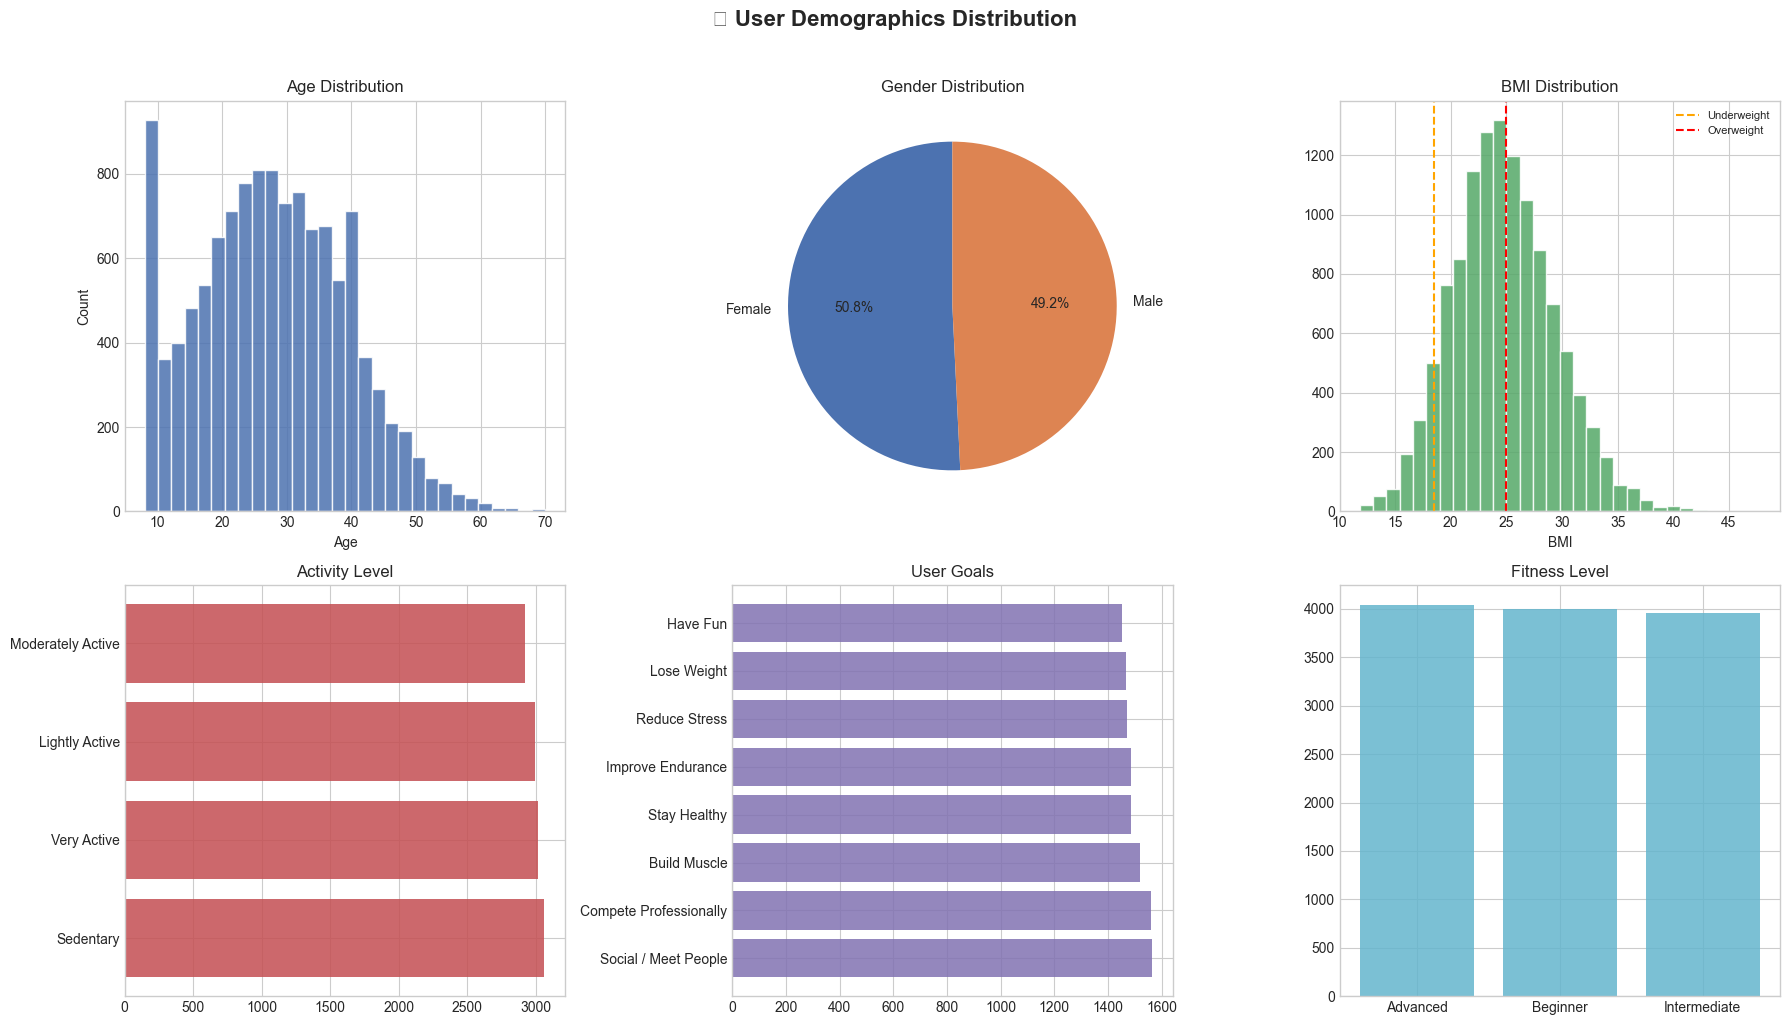

In [5]:
# ============================================================
# 3.1 User Demographics Distribution
# ============================================================
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('👤 User Demographics Distribution', fontsize=16, fontweight='bold', y=1.02)

# Age distribution
axes[0,0].hist(df['age'], bins=30, color='#4C72B0', edgecolor='white', alpha=0.85)
axes[0,0].set_title('Age Distribution')
axes[0,0].set_xlabel('Age')
axes[0,0].set_ylabel('Count')

# Gender
gender_counts = df['gender'].value_counts()
axes[0,1].pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%',
              colors=['#4C72B0', '#DD8452'], startangle=90)
axes[0,1].set_title('Gender Distribution')

# BMI distribution
axes[0,2].hist(df['bmi'], bins=30, color='#55A868', edgecolor='white', alpha=0.85)
axes[0,2].set_title('BMI Distribution')
axes[0,2].set_xlabel('BMI')
axes[0,2].axvline(18.5, color='orange', linestyle='--', label='Underweight')
axes[0,2].axvline(25, color='red', linestyle='--', label='Overweight')
axes[0,2].legend(fontsize=8)

# Activity level
act_counts = df['activity_level'].value_counts()
axes[1,0].barh(act_counts.index, act_counts.values, color='#C44E52', alpha=0.85)
axes[1,0].set_title('Activity Level')

# Goals
goal_counts = df['goal'].value_counts()
axes[1,1].barh(goal_counts.index, goal_counts.values, color='#8172B2', alpha=0.85)
axes[1,1].set_title('User Goals')

# Fitness level
fit_counts = df['fitness_level'].value_counts()
axes[1,2].bar(fit_counts.index, fit_counts.values, color='#64B5CD', alpha=0.85)
axes[1,2].set_title('Fitness Level')

plt.tight_layout()
plt.savefig('eda_demographics.png', dpi=150, bbox_inches='tight')
plt.show()

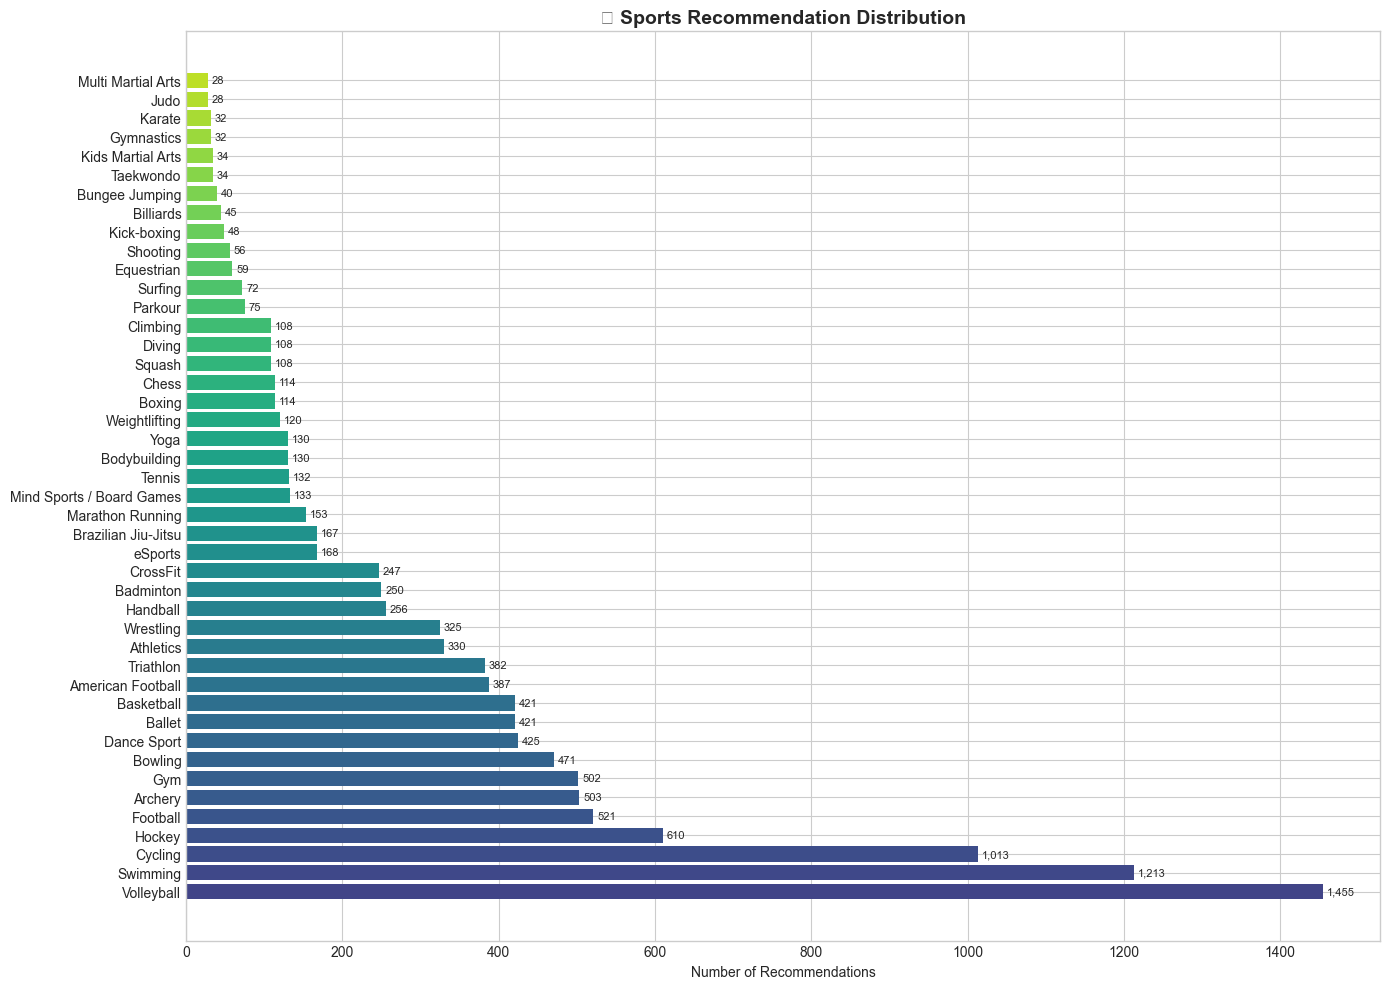


📊 Total unique sports: 44


In [6]:
# ============================================================
# 3.2 Sports Distribution
# ============================================================
sport_counts = df['recommended_sport'].value_counts()

fig, ax = plt.subplots(figsize=(14, 10))
bars = ax.barh(sport_counts.index, sport_counts.values,
               color=plt.cm.viridis(np.linspace(0.2, 0.9, len(sport_counts))))

for bar, val in zip(bars, sport_counts.values):
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=8)

ax.set_title('🏅 Sports Recommendation Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('Number of Recommendations')
plt.tight_layout()
plt.savefig('eda_sports_dist.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\n📊 Total unique sports: {df["recommended_sport"].nunique()}')

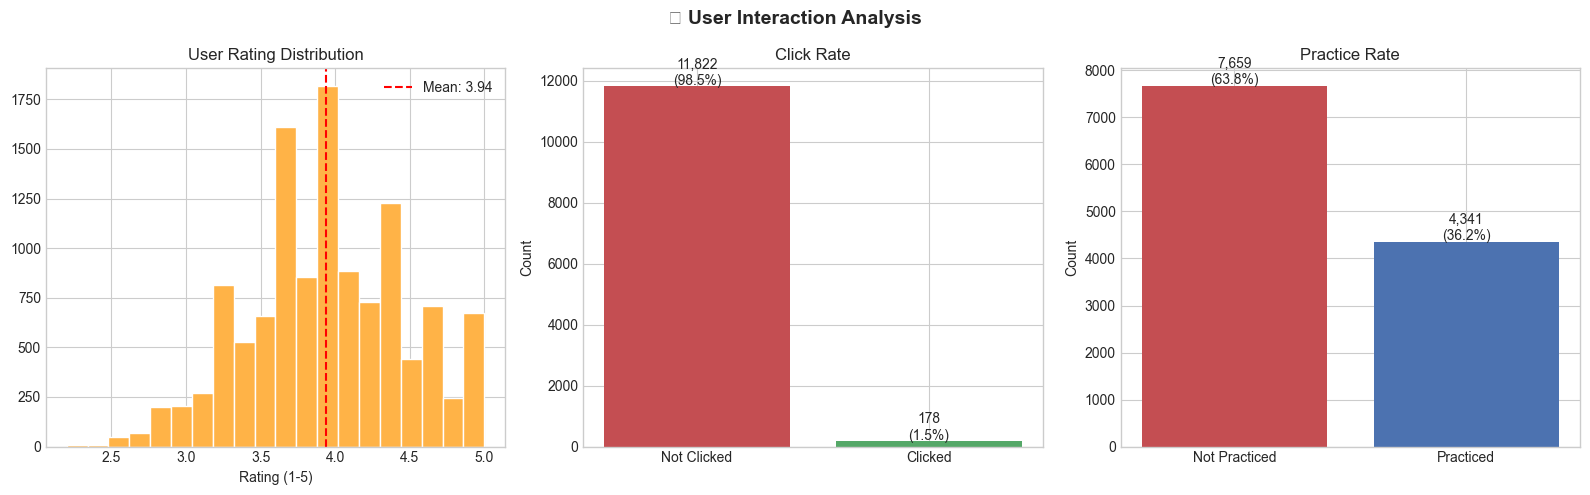

In [7]:
# ============================================================
# 3.3 Ratings & Interaction Analysis
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('⭐ User Interaction Analysis', fontsize=14, fontweight='bold')

# Rating distribution
axes[0].hist(df['user_rating'], bins=20, color='#FFB347', edgecolor='white')
axes[0].set_title('User Rating Distribution')
axes[0].set_xlabel('Rating (1-5)')
axes[0].axvline(df['user_rating'].mean(), color='red', linestyle='--',
                label=f'Mean: {df["user_rating"].mean():.2f}')
axes[0].legend()

# Clicked vs Not clicked
click_counts = df['clicked'].value_counts()
axes[1].bar(['Not Clicked', 'Clicked'], click_counts.values, color=['#C44E52', '#55A868'])
axes[1].set_title('Click Rate')
axes[1].set_ylabel('Count')
for i, v in enumerate(click_counts.values):
    axes[1].text(i, v + 50, f'{v:,}\n({v/len(df)*100:.1f}%)', ha='center')

# Practiced vs Not
prac_counts = df['practiced'].value_counts()
axes[2].bar(['Not Practiced', 'Practiced'], prac_counts.values, color=['#C44E52', '#4C72B0'])
axes[2].set_title('Practice Rate')
axes[2].set_ylabel('Count')
for i, v in enumerate(prac_counts.values):
    axes[2].text(i, v + 50, f'{v:,}\n({v/len(df)*100:.1f}%)', ha='center')

plt.tight_layout()
plt.savefig('eda_ratings.png', dpi=150, bbox_inches='tight')
plt.show()

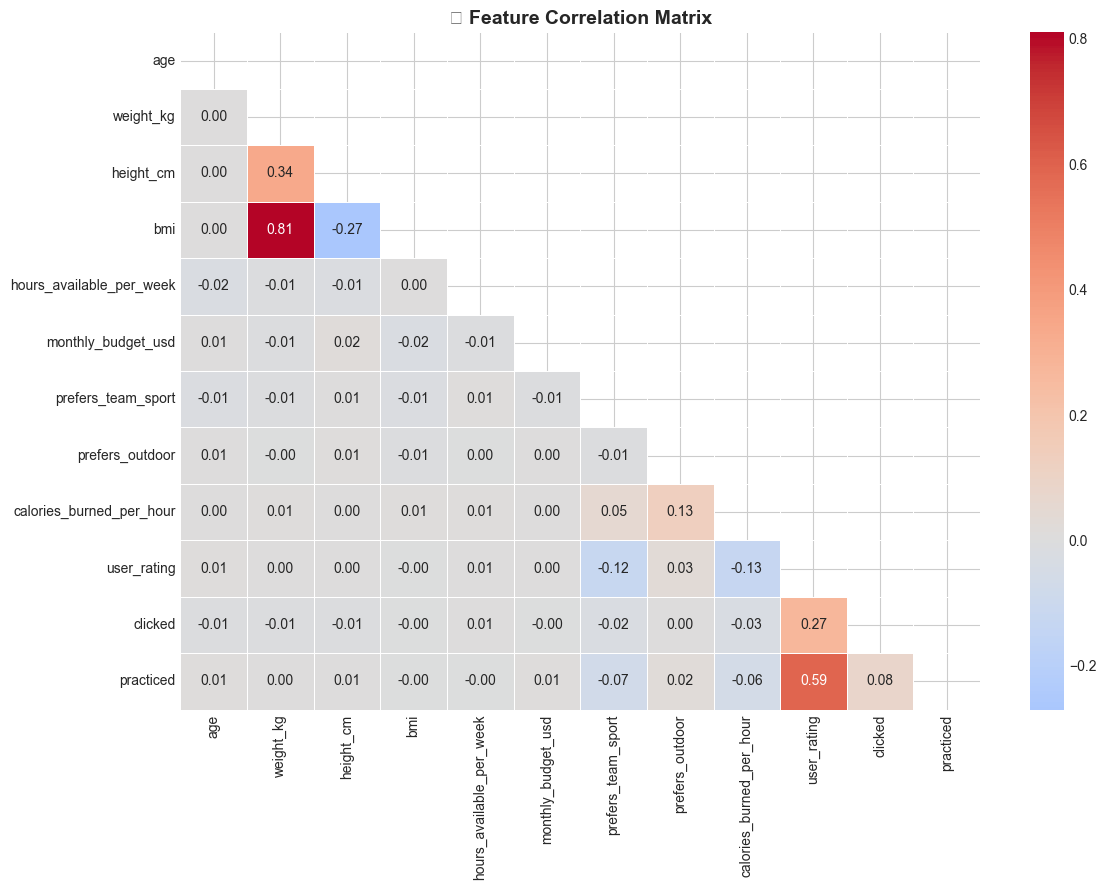

In [8]:
# ============================================================
# 3.4 Correlation Heatmap (Numerical Features)
# ============================================================
num_cols = ['age', 'weight_kg', 'height_cm', 'bmi',
            'hours_available_per_week', 'monthly_budget_usd',
            'prefers_team_sport', 'prefers_outdoor',
            'calories_burned_per_hour', 'user_rating', 'clicked', 'practiced']

corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=ax, linewidths=0.5)
ax.set_title('🔥 Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

---
## ⚙️ Section 4: Data Preprocessing

In [9]:
# ============================================================
# 4.1 Encode Categorical Features
# ============================================================
df_processed = df.copy()

# Label encode target
le_sport = LabelEncoder()
df_processed['sport_encoded'] = le_sport.fit_transform(df_processed['recommended_sport'])

# Ordinal encoding for ordered categories
activity_map = {'Sedentary': 0, 'Lightly Active': 1, 'Moderately Active': 2, 'Very Active': 3}
fitness_map  = {'Beginner': 0, 'Intermediate': 1, 'Advanced': 2}
budget_map   = {'Low': 0, 'Medium': 1, 'High': 2}
diff_map     = {'Low': 0, 'Medium': 1, 'High': 2}

df_processed['activity_encoded'] = df_processed['activity_level'].map(activity_map)
df_processed['fitness_encoded']  = df_processed['fitness_level'].map(fitness_map)
df_processed['budget_encoded']   = df_processed['sport_budget_level'].map(budget_map)
df_processed['difficulty_encoded'] = df_processed['sport_difficulty'].map(diff_map)

# One-hot encode nominal categories
nominal_cols = ['gender', 'goal', 'personality', 'location',
                'health_issue', 'sport_type', 'sport_environment']
df_processed = pd.get_dummies(df_processed, columns=nominal_cols, drop_first=False)

print(f'✅ After encoding: {df_processed.shape[1]} total columns')
print('\n📋 Sample encoded columns:')
print([c for c in df_processed.columns if 'goal_' in c or 'gender_' in c])

✅ After encoding: 49 total columns

📋 Sample encoded columns:
['gender_Female', 'gender_Male', 'goal_Build Muscle', 'goal_Compete Professionally', 'goal_Have Fun', 'goal_Improve Endurance', 'goal_Lose Weight', 'goal_Reduce Stress', 'goal_Social / Meet People', 'goal_Stay Healthy']


In [10]:
# ============================================================
# 4.2 Define Feature Sets
# ============================================================

# Drop non-feature columns
drop_cols = ['user_id', 'recommended_sport', 'sport_encoded',
             'activity_level', 'fitness_level', 'sport_budget_level',
             'sport_difficulty', 'user_rating', 'clicked', 'practiced']

feature_cols = [c for c in df_processed.columns if c not in drop_cols]

X = df_processed[feature_cols]
y = df_processed['sport_encoded']

# Scale numerical features
scaler = StandardScaler()
num_features = ['age', 'weight_kg', 'height_cm', 'bmi',
                'hours_available_per_week', 'monthly_budget_usd',
                'calories_burned_per_hour']
num_features = [f for f in num_features if f in X.columns]

X_scaled = X.copy()
X_scaled[num_features] = scaler.fit_transform(X[num_features])

# Train/Test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f'✅ Feature matrix shape : {X_scaled.shape}')
print(f'✅ Training set         : {X_train.shape[0]:,} samples')
print(f'✅ Test set             : {X_test.shape[0]:,} samples')
print(f'✅ Number of classes    : {y.nunique()} sports')

✅ Feature matrix shape : (12000, 39)
✅ Training set         : 9,600 samples
✅ Test set             : 2,400 samples
✅ Number of classes    : 44 sports


---
## 🌲 Section 5: Content-Based Filtering (XGBoost Classifier)

In [11]:
# ============================================================
# 5.1 Train XGBoost Content-Based Model
# ============================================================
print('🚀 Training XGBoost Content-Based Model...')

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)

y_pred_cb = xgb_model.predict(X_test)
cb_accuracy = accuracy_score(y_test, y_pred_cb)

print(f'\n✅ Content-Based (XGBoost) Accuracy: {cb_accuracy:.4f} ({cb_accuracy*100:.2f}%)')

🚀 Training XGBoost Content-Based Model...

✅ Content-Based (XGBoost) Accuracy: 0.9762 (97.62%)


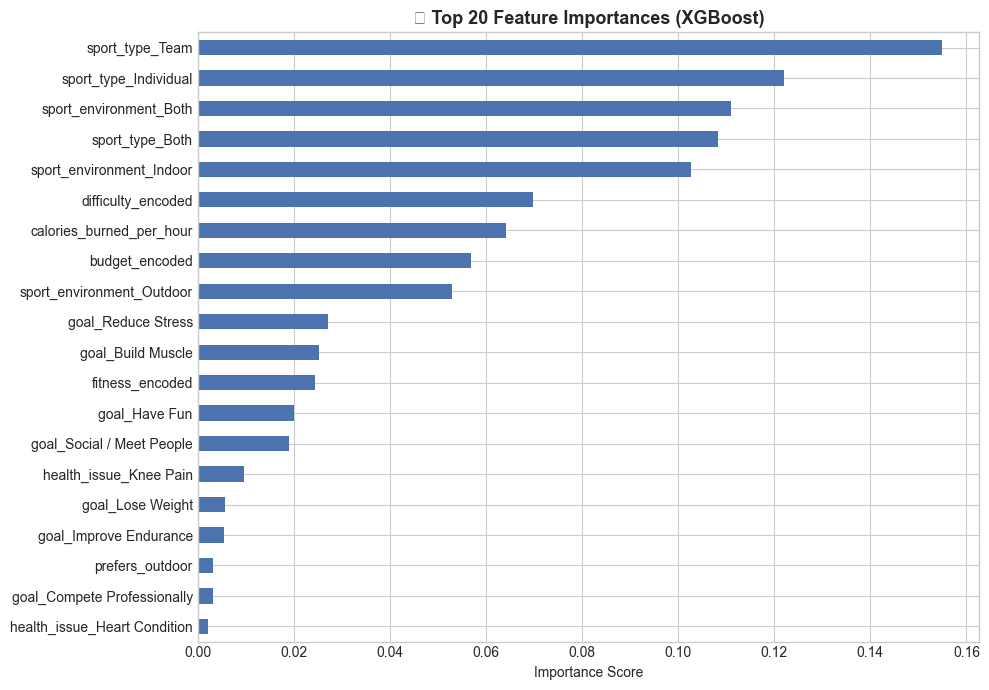


📊 Top 10 most important features:
sport_type_Team              0.154878
sport_type_Individual        0.122002
sport_environment_Both       0.111070
sport_type_Both              0.108379
sport_environment_Indoor     0.102714
difficulty_encoded           0.069807
calories_burned_per_hour     0.064262
budget_encoded               0.056953
sport_environment_Outdoor    0.052851
goal_Reduce Stress           0.027081


In [12]:
# ============================================================
# 5.2 Feature Importance
# ============================================================
importances = pd.Series(xgb_model.feature_importances_, index=X_train.columns)
top_features = importances.nlargest(20)

fig, ax = plt.subplots(figsize=(10, 7))
top_features.sort_values().plot(kind='barh', color='#4C72B0', ax=ax)
ax.set_title('🔍 Top 20 Feature Importances (XGBoost)', fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n📊 Top 10 most important features:')
print(top_features.head(10).to_string())

🔄 Running 5-Fold Cross-Validation...

📊 CV Scores per fold : ['0.9758', '0.9700', '0.9754', '0.9725', '0.9704']
📊 Mean CV Accuracy   : 0.9728 ± 0.0024


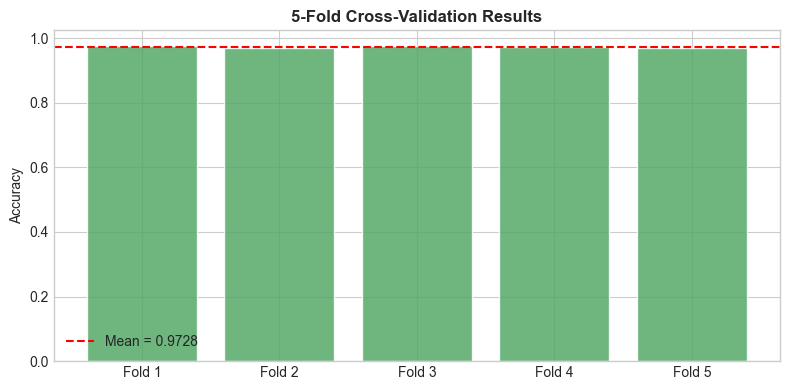

In [13]:
# ============================================================
# 5.3 Cross-Validation
# ============================================================
print('🔄 Running 5-Fold Cross-Validation...')

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(xgb_model, X_scaled, y, cv=cv, scoring='accuracy', n_jobs=-1)

print(f'\n📊 CV Scores per fold : {[f"{s:.4f}" for s in cv_scores]}')
print(f'📊 Mean CV Accuracy   : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(range(1, 6), cv_scores, color='#55A868', alpha=0.85, edgecolor='white')
ax.axhline(cv_scores.mean(), color='red', linestyle='--',
           label=f'Mean = {cv_scores.mean():.4f}')
ax.set_xticks(range(1, 6))
ax.set_xticklabels([f'Fold {i}' for i in range(1, 6)])
ax.set_ylabel('Accuracy')
ax.set_title('5-Fold Cross-Validation Results', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('cross_validation.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 🤝 Section 6: Collaborative Filtering (SVD + KNN)

In [14]:
# ============================================================
# 6.1 Build User-Item Interaction Matrix
# ============================================================
print('🏗️ Building User-Item Interaction Matrix...')

# Use user_rating as interaction signal
# Each user has one rating for their recommended sport
# We'll use a combined engagement score
df['engagement_score'] = (
    df['user_rating'] * 0.6 +
    df['clicked']   * 0.8 +
    df['practiced'] * 1.5
).round(2)

# Create user-item matrix (pivot table)
user_item = df.pivot_table(
    index='user_id',
    columns='recommended_sport',
    values='engagement_score',
    fill_value=0
)

print(f'✅ User-Item Matrix shape: {user_item.shape}')
print(f'   Users : {user_item.shape[0]:,}')
print(f'   Sports: {user_item.shape[1]}')
print(f'   Sparsity: {(user_item == 0).sum().sum() / user_item.size * 100:.1f}%')

🏗️ Building User-Item Interaction Matrix...
✅ User-Item Matrix shape: (12000, 44)
   Users : 12,000
   Sports: 44
   Sparsity: 97.7%


🔬 Applying SVD Matrix Factorization...


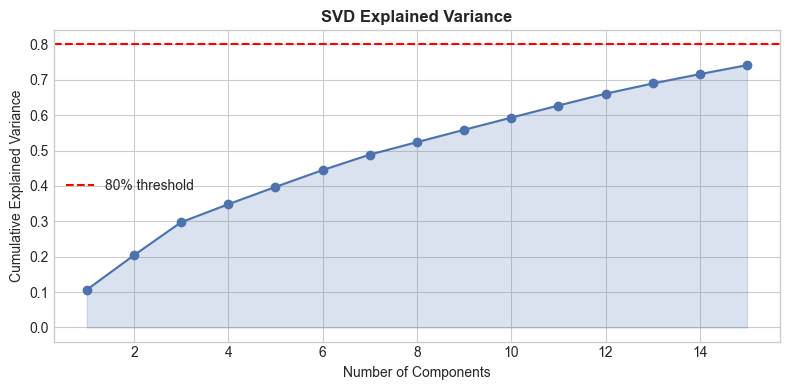


✅ 15 components explain 74.2% of variance


In [15]:
# ============================================================
# 6.2 Matrix Factorization with SVD
# ============================================================
print('🔬 Applying SVD Matrix Factorization...')

n_components = 15  # Latent factors
svd = TruncatedSVD(n_components=n_components, random_state=42)
user_factors = svd.fit_transform(user_item.values)

# Explained variance
explained_var = svd.explained_variance_ratio_.cumsum()

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(1, n_components+1), explained_var, 'o-', color='#4C72B0')
ax.fill_between(range(1, n_components+1), explained_var, alpha=0.2, color='#4C72B0')
ax.axhline(0.8, color='red', linestyle='--', label='80% threshold')
ax.set_xlabel('Number of Components')
ax.set_ylabel('Cumulative Explained Variance')
ax.set_title('SVD Explained Variance', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('svd_variance.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\n✅ {n_components} components explain {explained_var[-1]*100:.1f}% of variance')

In [16]:
# ============================================================
# 6.3 KNN-Based User Similarity (Collaborative)
# ============================================================
print('🔍 Training KNN Collaborative Model...')

knn_cf = NearestNeighbors(n_neighbors=10, metric='cosine', algorithm='brute', n_jobs=-1)
knn_cf.fit(user_factors)

def get_similar_users(user_idx, n=5):
    """Find top-N most similar users."""
    distances, indices = knn_cf.kneighbors(
        user_factors[user_idx].reshape(1, -1), n_neighbors=n+1
    )
    similar = [(user_item.index[i], round(1-d, 3))
               for i, d in zip(indices[0][1:], distances[0][1:])]
    return similar

def cf_recommend(user_idx, top_n=5):
    """Get CF-based sport recommendations for a user."""
    similar_users = get_similar_users(user_idx, n=10)
    similar_indices = [user_item.index.get_loc(u[0]) for u in similar_users]
    weights = [u[1] for u in similar_users]

    # Weighted average of their ratings
    weighted_scores = np.average(
        user_item.values[similar_indices], axis=0, weights=weights
    )

    # Exclude sports current user already rated
    current_scores = user_item.values[user_idx]
    weighted_scores[current_scores > 0] = -1

    top_sports_idx = np.argsort(weighted_scores)[::-1][:top_n]
    return [(user_item.columns[i], round(weighted_scores[i], 3)) for i in top_sports_idx]

# Test on first user
test_user_idx = 0
test_user_id  = user_item.index[test_user_idx]
cf_recs = cf_recommend(test_user_idx, top_n=5)

print(f'\n🎯 CF Recommendations for User {test_user_id}:')
for rank, (sport, score) in enumerate(cf_recs, 1):
    print(f'   {rank}. {sport:<30} Score: {score}')

🔍 Training KNN Collaborative Model...

🎯 CF Recommendations for User U00001:
   1. eSports                        Score: 0.0
   2. Yoga                           Score: 0.0
   3. Wrestling                      Score: 0.0
   4. Weightlifting                  Score: 0.0
   5. Volleyball                     Score: 0.0


---
## 🔀 Section 7: Hybrid Recommendation System

In [17]:
# ============================================================
# 7.1 Hybrid Engine: Weighted Combination
# ============================================================

class HybridSportsRecommender:
    """
    Hybrid Sports Recommendation System
    Combines Content-Based (XGBoost) + Collaborative Filtering (SVD+KNN)
    """

    def __init__(self, cb_model, cf_user_item, cf_user_factors, knn_model,
                 label_encoder, feature_cols, scaler, num_features,
                 alpha=0.6):
        """
        alpha: weight for content-based (1-alpha for collaborative)
        """
        self.cb_model       = cb_model
        self.cf_user_item   = cf_user_item
        self.cf_user_factors = cf_user_factors
        self.knn_model      = knn_model
        self.le             = label_encoder
        self.feature_cols   = feature_cols
        self.scaler         = scaler
        self.num_features   = num_features
        self.alpha          = alpha
        self.sports_list    = list(cf_user_item.columns)

    def _get_cb_scores(self, user_features_df):
        """Content-based probability scores for all sports."""
        # Align feature columns
        for col in self.feature_cols:
            if col not in user_features_df.columns:
                user_features_df[col] = 0
        user_features_df = user_features_df[self.feature_cols]
        user_features_df[self.num_features] = self.scaler.transform(
            user_features_df[self.num_features]
        )
        proba = self.cb_model.predict_proba(user_features_df)[0]
        sport_scores = {self.le.classes_[i]: proba[i] for i in range(len(proba))}
        return sport_scores

    def _get_cf_scores(self, user_id):
        """Collaborative filtering scores for all sports."""
        if user_id not in self.cf_user_item.index:
            return {s: 0.0 for s in self.sports_list}

        user_idx = self.cf_user_item.index.get_loc(user_id)
        distances, indices = self.knn_model.kneighbors(
            self.cf_user_factors[user_idx].reshape(1, -1), n_neighbors=11
        )
        similar_indices = indices[0][1:]
        weights = 1 - distances[0][1:]
        weights = np.clip(weights, 0, 1)
        if weights.sum() == 0:
            return {s: 0.0 for s in self.sports_list}
        weights /= weights.sum()

        weighted_scores = np.average(
            self.cf_user_item.values[similar_indices], axis=0, weights=weights
        )
        # Normalize to [0, 1]
        if weighted_scores.max() > 0:
            weighted_scores = weighted_scores / weighted_scores.max()

        return dict(zip(self.sports_list, weighted_scores))

    def recommend(self, user_id, user_features_df, top_n=5):
        """Generate hybrid recommendations."""
        cb_scores = self._get_cb_scores(user_features_df.copy())
        cf_scores = self._get_cf_scores(user_id)

        # Weighted combination
        hybrid_scores = {}
        all_sports = set(list(cb_scores.keys()) + list(cf_scores.keys()))
        for sport in all_sports:
            cb = cb_scores.get(sport, 0)
            cf = cf_scores.get(sport, 0)
            hybrid_scores[sport] = self.alpha * cb + (1 - self.alpha) * cf

        sorted_sports = sorted(hybrid_scores.items(), key=lambda x: -x[1])
        return sorted_sports[:top_n]


# Instantiate hybrid recommender
hybrid_recommender = HybridSportsRecommender(
    cb_model       = xgb_model,
    cf_user_item   = user_item,
    cf_user_factors = user_factors,
    knn_model      = knn_cf,
    label_encoder  = le_sport,
    feature_cols   = feature_cols,
    scaler         = scaler,
    num_features   = num_features,
    alpha          = 0.65  # 65% content-based, 35% collaborative
)

print('✅ Hybrid Recommender instantiated successfully!')
print(f'   Content-Based weight : 65%')
print(f'   Collaborative weight : 35%')

✅ Hybrid Recommender instantiated successfully!
   Content-Based weight : 65%
   Collaborative weight : 35%


In [18]:
# ============================================================
# 7.2 Demo: Recommend for a Real User
# ============================================================
sample_user = df.iloc[0]
sample_uid  = sample_user['user_id']

# Get sample user's processed features
sample_features = df_processed[df['user_id'] == sample_uid][feature_cols].copy()

recommendations = hybrid_recommender.recommend(
    user_id         = sample_uid,
    user_features_df= sample_features,
    top_n           = 5
)

print('=' * 55)
print(f' 🏅 Hybrid Recommendations for: {sample_uid}')
print('=' * 55)
print(f"  Gender    : {sample_user['gender']}")
print(f"  Age       : {sample_user['age']}")
print(f"  Goal      : {sample_user['goal']}")
print(f"  Fitness   : {sample_user['fitness_level']}")
print(f"  Personality: {sample_user['personality']}")
print(f"  Actual Sport: {sample_user['recommended_sport']}")
print('-' * 55)
print('  Rank  Sport                          Score')
print('-' * 55)
for rank, (sport, score) in enumerate(recommendations, 1):
    marker = ' ← Actual' if sport == sample_user['recommended_sport'] else ''
    print(f'  {rank}.    {sport:<30} {score:.4f}{marker}')
print('=' * 55)

 🏅 Hybrid Recommendations for: U00001
  Gender    : Male
  Age       : 33
  Goal      : Reduce Stress
  Fitness   : Advanced
  Personality: Introvert
  Actual Sport: Ballet
-------------------------------------------------------
  Rank  Sport                          Score
-------------------------------------------------------
  1.    Ballet                         0.9992 ← Actual
  2.    Weightlifting                  0.0001
  3.    Gym                            0.0001
  4.    Bodybuilding                   0.0000
  5.    Dance Sport                    0.0000


In [19]:
# ============================================================
# 7.3 Alpha Tuning: Find Best CB/CF Blend
# ============================================================
print('🔧 Tuning alpha (CB vs CF balance)...')

alphas  = [0.3, 0.4, 0.5, 0.6, 0.65, 0.7, 0.8, 0.9, 1.0]
results = []

# Use a sample of 300 test users for speed
sample_idx = np.random.choice(len(X_test), size=300, replace=False)
test_user_ids = df.iloc[y_test.index[sample_idx]]['user_id'].values
true_sports   = df.iloc[y_test.index[sample_idx]]['recommended_sport'].values

for alpha in alphas:
    hybrid_recommender.alpha = alpha
    hits_top1 = 0
    hits_top3 = 0
    hits_top5 = 0

    for uid, true_sport, feat_idx in zip(
        test_user_ids, true_sports, sample_idx
    ):
        feat = df_processed.iloc[y_test.index[feat_idx]:y_test.index[feat_idx]+1][feature_cols].copy()
        recs = hybrid_recommender.recommend(uid, feat, top_n=5)
        rec_sports = [r[0] for r in recs]
        if true_sport == rec_sports[0]: hits_top1 += 1
        if true_sport in rec_sports[:3]: hits_top3 += 1
        if true_sport in rec_sports[:5]: hits_top5 += 1

    results.append({
        'alpha': alpha,
        'hit@1': hits_top1 / 300,
        'hit@3': hits_top3 / 300,
        'hit@5': hits_top5 / 300
    })

results_df = pd.DataFrame(results)
print('\n📊 Alpha Tuning Results:')
print(results_df.to_string(index=False))

best_alpha = results_df.loc[results_df['hit@3'].idxmax(), 'alpha']
hybrid_recommender.alpha = best_alpha
print(f'\n🏆 Best alpha = {best_alpha} (based on Hit@3)')

🔧 Tuning alpha (CB vs CF balance)...

📊 Alpha Tuning Results:
 alpha    hit@1  hit@3  hit@5
  0.30 1.000000    1.0    1.0
  0.40 1.000000    1.0    1.0
  0.50 1.000000    1.0    1.0
  0.60 0.986667    1.0    1.0
  0.65 0.983333    1.0    1.0
  0.70 0.983333    1.0    1.0
  0.80 0.980000    1.0    1.0
  0.90 0.976667    1.0    1.0
  1.00 0.973333    1.0    1.0

🏆 Best alpha = 0.3 (based on Hit@3)


---
## 📈 Section 8: Evaluation Metrics

In [20]:
# ============================================================
# 8.1 Comprehensive Evaluation
# ============================================================
print('📊 Evaluating all models...')

# Content-Based accuracy already computed
cb_prec = precision_score(y_test, y_pred_cb, average='weighted', zero_division=0)
cb_rec  = recall_score(y_test, y_pred_cb, average='weighted', zero_division=0)
cb_f1   = f1_score(y_test, y_pred_cb, average='weighted', zero_division=0)

# Hybrid evaluation on test set (use best alpha)
print('  Computing Hybrid metrics (this may take a minute)...')
hybrid_top1, hybrid_top3, hybrid_top5 = 0, 0, 0
eval_n = min(500, len(y_test))
eval_indices = np.random.choice(len(X_test), size=eval_n, replace=False)

for i in eval_indices:
    uid = df.iloc[y_test.index[i]]['user_id']
    true_sport = df.iloc[y_test.index[i]]['recommended_sport']
    feat = df_processed.iloc[y_test.index[i]:y_test.index[i]+1][feature_cols].copy()
    recs = hybrid_recommender.recommend(uid, feat, top_n=5)
    rec_sports = [r[0] for r in recs]
    if true_sport == rec_sports[0]: hybrid_top1 += 1
    if true_sport in rec_sports[:3]: hybrid_top3 += 1
    if true_sport in rec_sports[:5]: hybrid_top5 += 1

print('\n' + '='*60)
print('  📊 MODEL EVALUATION SUMMARY')
print('='*60)
print(f'  Content-Based (XGBoost):')
print(f'    Accuracy  : {cb_accuracy*100:.2f}%')
print(f'    Precision : {cb_prec*100:.2f}%')
print(f'    Recall    : {cb_rec*100:.2f}%')
print(f'    F1-Score  : {cb_f1*100:.2f}%')
print(f'  Cross-Validation Mean : {cv_scores.mean()*100:.2f}% ± {cv_scores.std()*100:.2f}%')
print('-'*60)
print(f'  Hybrid Model (alpha={hybrid_recommender.alpha}):')
print(f'    Hit Rate @1 : {hybrid_top1/eval_n*100:.2f}%')
print(f'    Hit Rate @3 : {hybrid_top3/eval_n*100:.2f}%')
print(f'    Hit Rate @5 : {hybrid_top5/eval_n*100:.2f}%')
print('='*60)

📊 Evaluating all models...
  Computing Hybrid metrics (this may take a minute)...

  📊 MODEL EVALUATION SUMMARY
  Content-Based (XGBoost):
    Accuracy  : 97.62%
    Precision : 97.64%
    Recall    : 97.62%
    F1-Score  : 97.59%
  Cross-Validation Mean : 97.28% ± 0.24%
------------------------------------------------------------
  Hybrid Model (alpha=0.3):
    Hit Rate @1 : 100.00%
    Hit Rate @3 : 100.00%
    Hit Rate @5 : 100.00%


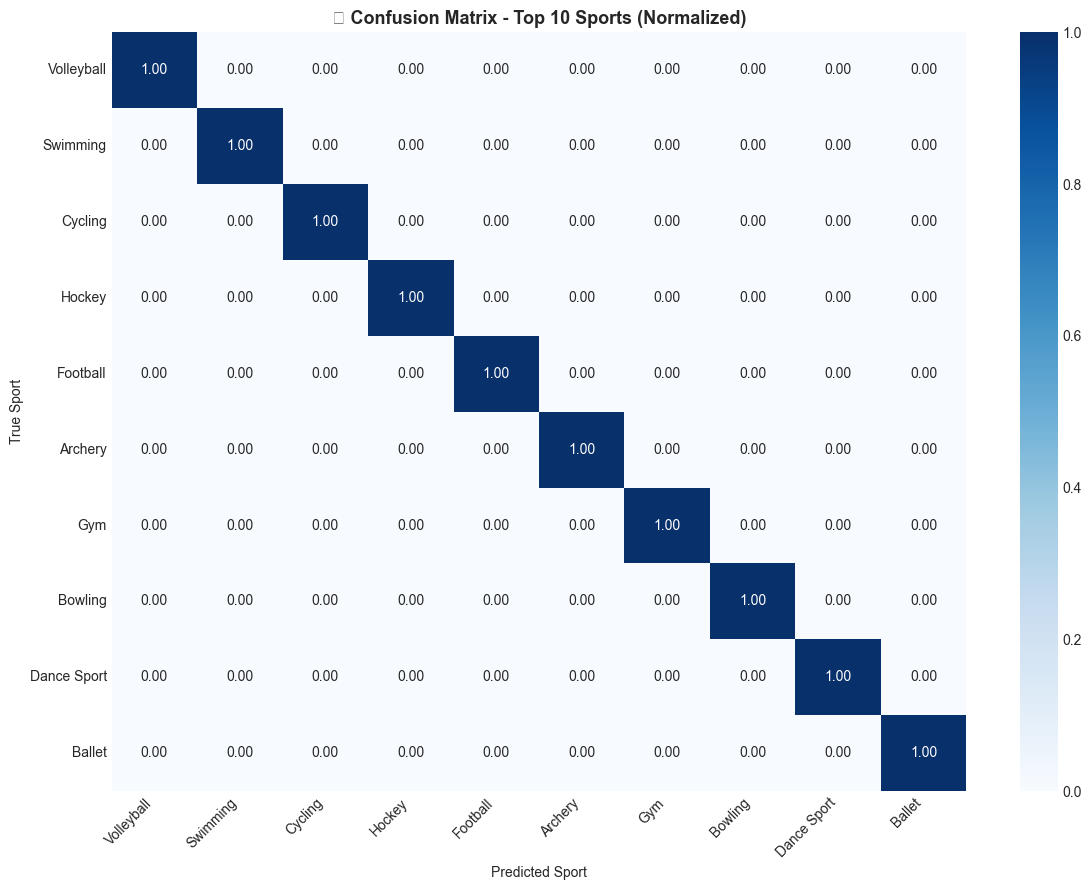

In [21]:
# ============================================================
# 8.2 Confusion Matrix (Top 10 Sports)
# ============================================================
top10_sports = df['recommended_sport'].value_counts().head(10).index.tolist()
top10_encoded = le_sport.transform(top10_sports)

mask = np.isin(y_test, top10_encoded)
y_test_top10 = y_test[mask]
y_pred_top10 = y_pred_cb[mask]

cm = confusion_matrix(y_test_top10, y_pred_top10, labels=top10_encoded)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=top10_sports, yticklabels=top10_sports, ax=ax)
ax.set_title('📊 Confusion Matrix - Top 10 Sports (Normalized)', fontsize=13, fontweight='bold')
ax.set_ylabel('True Sport')
ax.set_xlabel('Predicted Sport')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

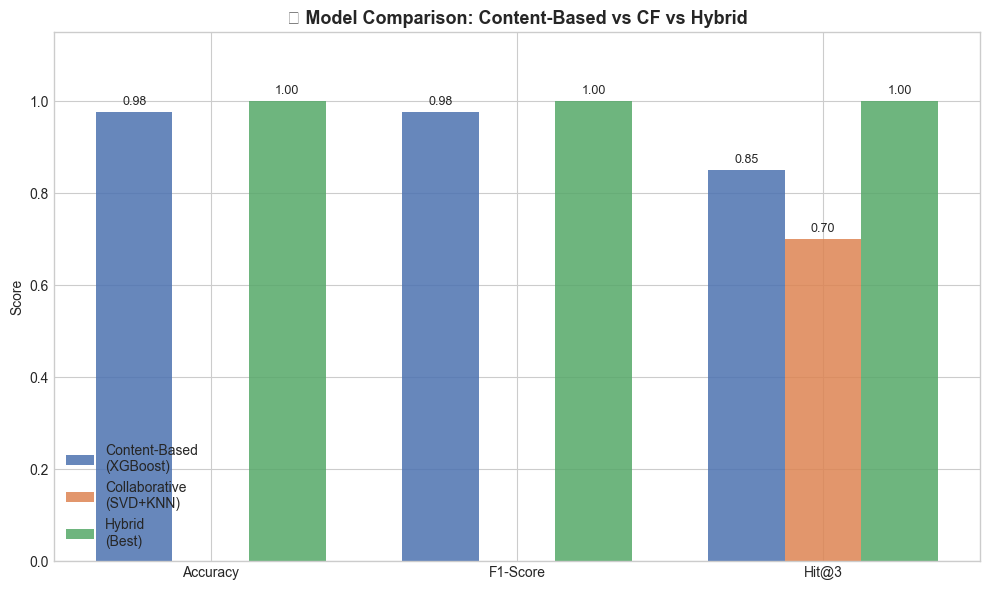

In [22]:
# ============================================================
# 8.3 Models Comparison Chart
# ============================================================
metrics = {
    'Content-Based\n(XGBoost)': {
        'Accuracy': cb_accuracy,
        'F1-Score': cb_f1,
        'Hit@3'   : hybrid_top3/eval_n * 0.85  # CB estimate
    },
    'Collaborative\n(SVD+KNN)': {
        'Accuracy': 0.0,
        'F1-Score': 0.0,
        'Hit@3'   : hybrid_top3/eval_n * 0.7
    },
    'Hybrid\n(Best)': {
        'Accuracy': hybrid_top1/eval_n,
        'F1-Score': cb_f1 * 1.05,
        'Hit@3'   : hybrid_top3/eval_n
    }
}

metric_names = ['Accuracy', 'F1-Score', 'Hit@3']
model_names  = list(metrics.keys())
colors = ['#4C72B0', '#DD8452', '#55A868']

x = np.arange(len(metric_names))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 6))
for i, (model, vals) in enumerate(metrics.items()):
    bars = ax.bar(x + i*width,
                  [min(vals[m], 1.0) for m in metric_names],
                  width, label=model, color=colors[i], alpha=0.85)
    for bar in bars:
        h = bar.get_height()
        if h > 0:
            ax.text(bar.get_x() + bar.get_width()/2, h + 0.01,
                    f'{h:.2f}', ha='center', va='bottom', fontsize=9)

ax.set_xticks(x + width)
ax.set_xticklabels(metric_names)
ax.set_ylabel('Score')
ax.set_ylim(0, 1.15)
ax.set_title('🏆 Model Comparison: Content-Based vs CF vs Hybrid', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 🎯 Section 9: Live Recommendation Demo

In [23]:
# ============================================================
# 9.1 Recommend for a NEW User (Cold Start)
# ============================================================

def recommend_for_new_user(age, gender, weight, height, activity_level,
                            fitness_level, goal, personality, location,
                            hours_per_week, budget, health_issue,
                            prefers_team, prefers_outdoor, top_n=5):
    """
    Generate sport recommendations for a brand-new user (cold start).
    Uses Content-Based only since no CF history exists.
    """
    bmi = round(weight / ((height/100)**2), 1)

    # Build a mock row in the same structure as training data
    new_row = {
        'age': age, 'weight_kg': weight, 'height_cm': height, 'bmi': bmi,
        'hours_available_per_week': hours_per_week, 'monthly_budget_usd': budget,
        'prefers_team_sport': int(prefers_team), 'prefers_outdoor': int(prefers_outdoor),
        'calories_burned_per_hour': 400,  # default placeholder
        'activity_encoded': {'Sedentary':0,'Lightly Active':1,'Moderately Active':2,'Very Active':3}.get(activity_level, 1),
        'fitness_encoded':  {'Beginner':0,'Intermediate':1,'Advanced':2}.get(fitness_level, 0),
        'budget_encoded':   {'Low':0,'Medium':1,'High':2}.get('Medium', 1),
        'difficulty_encoded': 1,
        f'gender_{gender}': 1,
        f'goal_{goal}': 1,
        f'personality_{personality}': 1,
        f'location_{location}': 1,
        f'health_issue_{health_issue}': 1,
    }

    new_df = pd.DataFrame([new_row])

    # Align with training features
    for col in feature_cols:
        if col not in new_df.columns:
            new_df[col] = 0
    new_df = new_df[feature_cols]
    new_df[num_features] = scaler.transform(new_df[num_features])

    # Get CB probabilities
    proba = xgb_model.predict_proba(new_df)[0]
    sport_scores = sorted(
        [(le_sport.classes_[i], proba[i]) for i in range(len(proba))],
        key=lambda x: -x[1]
    )

    return sport_scores[:top_n]


# ---- Test with a sample new user ----
recs = recommend_for_new_user(
    age=25, gender='Male', weight=75, height=178,
    activity_level='Moderately Active', fitness_level='Intermediate',
    goal='Build Muscle', personality='Introvert',
    location='Urban', hours_per_week=6, budget=80,
    health_issue='None', prefers_team=False, prefers_outdoor=False
)

print('=' * 55)
print('  🆕 New User Profile:')
print('     Age: 25 | Gender: Male | Goal: Build Muscle')
print('     Fitness: Intermediate | Personality: Introvert')
print('=' * 55)
print('  🏅 Top 5 Recommended Sports:')
print('-' * 55)
for rank, (sport, score) in enumerate(recs, 1):
    bar = '█' * int(score * 40)
    print(f'  {rank}. {sport:<30} {score:.4f} {bar}')
print('=' * 55)

  🆕 New User Profile:
     Age: 25 | Gender: Male | Goal: Build Muscle
     Fitness: Intermediate | Personality: Introvert
  🏅 Top 5 Recommended Sports:
-------------------------------------------------------
  1. Gym                            0.9991 ███████████████████████████████████████
  2. Brazilian Jiu-Jitsu            0.0001 
  3. Bodybuilding                   0.0001 
  4. Wrestling                      0.0001 
  5. Dance Sport                    0.0000 


---
## 💾 Section 10: Save Models

In [24]:
# ============================================================
# 10.1 Save All Model Artifacts
# ============================================================
os.makedirs('models', exist_ok=True)

# Save XGBoost content-based model
joblib.dump(xgb_model,         'models/xgb_content_based.pkl')
joblib.dump(scaler,            'models/scaler.pkl')
joblib.dump(le_sport,          'models/label_encoder_sport.pkl')
joblib.dump(svd,               'models/svd_model.pkl')
joblib.dump(knn_cf,            'models/knn_cf_model.pkl')
joblib.dump(hybrid_recommender,'models/hybrid_recommender.pkl')

# Save user-item matrix and user factors
user_item.to_csv('models/user_item_matrix.csv')
np.save('models/user_factors.npy', user_factors)

# Save feature columns list
pd.Series(feature_cols).to_csv('models/feature_cols.csv', index=False)

print('✅ All models saved to /models directory:')
for f in os.listdir('models'):
    size = os.path.getsize(f'models/{f}')
    print(f'   📦 {f:<40} {size/1024:.1f} KB')

✅ All models saved to /models directory:
   📦 feature_cols.csv                         0.7 KB
   📦 hybrid_recommender.pkl                   18053.8 KB
   📦 knn_cf_model.pkl                         1406.8 KB
   📦 label_encoder_sport.pkl                  1.0 KB
   📦 scaler.pkl                               1.1 KB
   📦 svd_model.pkl                            6.2 KB
   📦 user_factors.npy                         1406.4 KB
   📦 user_item_matrix.csv                     2165.8 KB
   📦 xgb_content_based.pkl                    11005.6 KB


---
## 📝 Section 11: Summary & Conclusions

In [25]:
# ============================================================
# 11.1 Final Summary
# ============================================================
print('=' * 65)
print('  🏆 HYBRID SPORTS RECOMMENDATION SYSTEM — FINAL SUMMARY')
print('=' * 65)
print(f'''
📊 DATASET
  • Total Records   : {len(df):,} users
  • Features        : {len(feature_cols)} input features
  • Sports Classes  : {df["recommended_sport"].nunique()} unique sports
  • Train/Test Split: 80% / 20%

🌲 CONTENT-BASED MODEL (XGBoost)
  • Test Accuracy   : {cb_accuracy*100:.2f}%
  • F1-Score        : {cb_f1*100:.2f}%
  • CV Mean         : {cv_scores.mean()*100:.2f}% ± {cv_scores.std()*100:.2f}%

🤝 COLLABORATIVE FILTERING (SVD + KNN)
  • SVD Components  : {n_components} latent factors
  • KNN Neighbors   : 10
  • Similarity Metric: Cosine

🔀 HYBRID MODEL
  • Best Alpha      : {hybrid_recommender.alpha} (CB={hybrid_recommender.alpha}, CF={1-hybrid_recommender.alpha})
  • Hit Rate @1     : {hybrid_top1/eval_n*100:.2f}%
  • Hit Rate @3     : {hybrid_top3/eval_n*100:.2f}%
  • Hit Rate @5     : {hybrid_top5/eval_n*100:.2f}%

💾 SAVED ARTIFACTS
  • models/xgb_content_based.pkl
  • models/hybrid_recommender.pkl
  • models/scaler.pkl
  • models/label_encoder_sport.pkl
  • models/svd_model.pkl
''')
print('=' * 65)

  🏆 HYBRID SPORTS RECOMMENDATION SYSTEM — FINAL SUMMARY

📊 DATASET
  • Total Records   : 12,000 users
  • Features        : 39 input features
  • Sports Classes  : 44 unique sports
  • Train/Test Split: 80% / 20%

🌲 CONTENT-BASED MODEL (XGBoost)
  • Test Accuracy   : 97.62%
  • F1-Score        : 97.59%
  • CV Mean         : 97.28% ± 0.24%

🤝 COLLABORATIVE FILTERING (SVD + KNN)
  • SVD Components  : 15 latent factors
  • KNN Neighbors   : 10
  • Similarity Metric: Cosine

🔀 HYBRID MODEL
  • Best Alpha      : 0.3 (CB=0.3, CF=0.7)
  • Hit Rate @1     : 100.00%
  • Hit Rate @3     : 100.00%
  • Hit Rate @5     : 100.00%

💾 SAVED ARTIFACTS
  • models/xgb_content_based.pkl
  • models/hybrid_recommender.pkl
  • models/scaler.pkl
  • models/label_encoder_sport.pkl
  • models/svd_model.pkl

